# 03: Pipeline

`int8 in -> ternary GEMM (int32) -> PLAC activation (int32 shifts) -> rescale to int8 -> next layer`

In [1]:
import pathlib
import sys

sys.path.insert(0, str(pathlib.Path("../")))

import matplotlib.pyplot as plt
import numpy as np
import torch

## Ternary GEMM: why no multiply

Standard matmul: $y_j = \sum_i w_{ji} \cdot x_i$ (multiply-accumulate)

Ternary weights $w \in \{-1, 0, +1\}$:

$$y_j = \sum_{i: w=+1} x_i - \sum_{i: w=-1} x_i$$

Additions and subtractions only, the positions are known at compile time (bitmasks).

In [2]:
x = np.array([10, -3, 7, 0, 5, -2, 8, 1], dtype=np.int8)
w = np.array([1, -1, 0, 1, -1, 0, 1, 1], dtype=np.int8)

# standard: 8 multiplies + 7 adds
y_std = np.sum(x * w)

# ternary: 0 multiplies, just conditional adds
y_add = np.sum(x[w == 1]) - np.sum(x[w == -1])

print(f"standard mul-acc: {y_std}")
print(f"ternary add/sub: {y_add}")
print(f"match: {y_std == y_add}")

standard mul-acc: 17
ternary add/sub: 17
match: True


## Bitmask packing

Store which positions are +1 and which are -1 as bit arrays.

| weight | val bit | sign bit | meaning |
|:------:|:-------:|:--------:|:--------|
| +1     | 1       | 0        | active, positive |
|  0     | 0       | 0        | skip |
| -1     | 1       | 1        | active, negative |

8 weights per byte. A 4096-dim weight row = 512 bytes (vs 16KB float32).

In [3]:
val_bits = (w != 0).astype(np.uint8)
sign_bits = (w == -1).astype(np.uint8)

# pack 8 bits into one byte (LSB-first)
powers = np.array([1, 2, 4, 8, 16, 32, 64, 128], dtype=np.uint8)
val_byte = np.sum(val_bits * powers)
sign_byte = np.sum(sign_bits * powers)

print(f"weights:  {w}")
print(f"val byte: {val_byte:08b} ({val_byte})")
print(f"sign byte: {sign_byte:08b} ({sign_byte})")
print(f"pos = val & ~sign: {val_byte & ~sign_byte & 0xFF:08b}")
print(f"neg = val &  sign: {val_byte & sign_byte:08b}")

weights:  [ 1 -1  0  1 -1  0  1  1]
val byte: 11011011 (219)
sign byte: 00010010 (18)
pos = val & ~sign: 11001001
neg = val &  sign: 00010010


## SIMD kernel: 32 elements per instruction

AVX2 processes 32 int8 values in one 256-bit register.

Per step:
1. Load 32 activations (one `_mm256_loadu`)
2. Load 4 bytes of val/sign = 32 weight bits
3. Expand bits to byte mask (`expand_mask`)
4. Select activations where pos/neg (`blendv`)
5. Widen int8 -> int16 -> int32 and accumulate (`madd_epi16`)

No multiply instruction in the loop. The `madd_epi16` with `ones` is just pairwise addition.

## PLAC: why shifts replace multiplies

A piecewise linear activation:
$$f(x) \approx m_i \cdot x + b_i \text{ on segment } [x_i, x_{i+1}]$$

Normal PWL needs a float multiply ($m_i \cdot x$).

ML-PLAC constrains slopes to sums of signed powers of 2:
$$m_i = \sum_k s_k \cdot 2^{e_k}$$

Then $m_i \cdot x$ becomes shifts and adds:
$$0.75 \cdot x = (2^0 - 2^{-2}) \cdot x = x - (x \gg 2)$$

In [4]:
from smelt.plac import quantize_slope, terms_to_str

slopes = [0.75, 0.42, 0.9, -0.18]
print(f"{'slope':>8s}  {'shift expression':>24s}  {'approx':>8s}  {'error':>8s}")
for s in slopes:
    terms, val = quantize_slope(s, n_terms=2)
    print(f"{s:>8.3f}  {terms_to_str(terms):>24s}  {val:>8.4f}  {abs(s - val):>8.4f}")

   slope          shift expression    approx     error
   0.750               x>>1 + x>>2    0.7500    0.0000
   0.420               x>>1 - x>>4    0.4375    0.0175
   0.900                  x - x>>3    0.8750    0.0250
  -0.180              -x>>3 - x>>4   -0.1875    0.0075


## Fixed-point: Q16.16

All PLAC evaluation happens in int32 using Q16.16 fixed-point:
- 16 bits integer, 16 bits fraction
- `x_fixed = round(x_float * 65536)`
- Shift right = divide by power of 2
- Add intercept = integer add

No float ops in the activation eval. Output stays int32 for the next layer.

In [5]:
from smelt.plac import from_fixed, to_fixed

# 0.75 * 3.5 using only shifts
x = to_fixed(np.array([3.5]))[0]

# 0.75 = 1 - 0.25 = 2^0 - 2^(-2)
y = x - (x >> 2)  # shift right by 2 = divide by 4

print(f"x fixed:       {x} (= {from_fixed(np.array([x]))[0]:.4f})")
print(f"x - (x >> 2):  {y} (= {from_fixed(np.array([y]))[0]:.4f})")
print(f"expected:       {0.75 * 3.5:.4f}")

x fixed:       229376 (= 3.5000)
x - (x >> 2):  172032 (= 2.6250)
expected:       2.6250


## Full layer + SiLU activation.

In [6]:
import torch.nn as nn

from smelt.plac import PLACFunc
from smelt.quantize import TernaryLinear


def silu(x):
    return torch.nn.functional.silu(x.float()).to(x.dtype)


torch.manual_seed(0)
linear = nn.Linear(256, 128, bias=False)
x = torch.randn(16, 256)

# float reference
y_ref = torch.nn.functional.silu(linear(x))

# smelt pipeline
tl = TernaryLinear(linear)
plac_silu = PLACFunc(silu, -8, 8, target_mae=1e-2)
y_smelt = plac_silu(tl(x))

nmse = ((y_ref - y_smelt) ** 2).mean() / (y_ref**2).mean()
print(f"NMSE (ternary GEMM + PLAC SiLU vs float): {nmse:.4f}")

NMSE (ternary GEMM + PLAC SiLU vs float): 0.1645


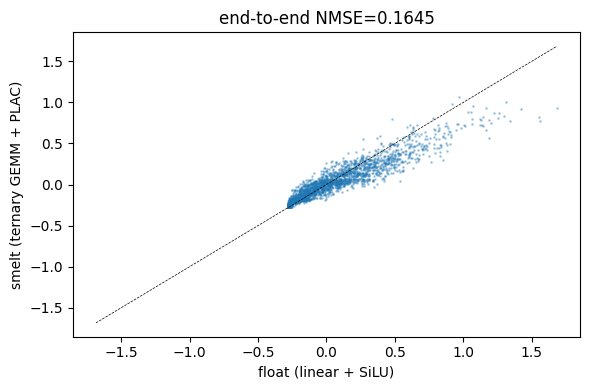

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(
    y_ref.detach().flatten().numpy(),
    y_smelt.detach().flatten().numpy(),
    s=1,
    alpha=0.3,
)
lim = max(y_ref.abs().max().item(), y_smelt.abs().max().item())
ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.5)
ax.set_xlabel("float (linear + SiLU)")
ax.set_ylabel("smelt (ternary GEMM + PLAC)")
ax.set_title(f"end-to-end NMSE={nmse:.4f}")
plt.tight_layout()
plt.show()